# 5. Trees

Stem detection and DBH, segmentation of the cloud into trees, heights and
crown metrics, on a height-normalised cloud (notebook 4).

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import sylva
from sylva import synthetic

DATA = Path("data")          # the Litchfield tile, cut by make_litch_subset.py
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (7, 4), "axes.grid": False})
from sylva import filters, ground, trees

cloud = filters.voxel_downsample(sylva.read(DATA / "litch_tile.laz"), 0.02)
dtm = ground.make_dtm(ground.classify_ground_pmf(cloud), 0.5, bounds=(0, 0, 20, 20))
cloud = ground.normalize_height(cloud, dtm)

## Stems

`detect_stems` fits RANSAC circles in horizontal slices from 1 to 5 m, links
them vertically, and reports DBH at 1.3 m with quality measures. It favours
recall: the candidates below include shrubs and low branches, which the next
steps remove.

In [2]:
stems = trees.detect_stems(cloud)
print(f"{len(stems)} candidates")
print(f"{'id':>3} {'x':>6} {'y':>6} {'dbh':>6} {'cover':>6} {'slices':>6} {'rmse':>6} {'quality':>7}")
for t in stems[:12]:
    print(f"{t.tree_id:>3} {t.x:6.2f} {t.y:6.2f} {t.dbh:6.3f} {t.inlier_fraction:6.2f} "
          f"{t.n_slices:>6} {t.rmse:6.3f} {t.quality:7.2f}")

54 candidates
 id      x      y    dbh  cover slices   rmse quality
  1   4.77   7.47  0.316   0.95     15  0.009    0.49
  2  18.20   8.45  0.304   0.92     17  0.009    0.48
  3  15.52  16.52  0.195   0.87     17  0.008    0.47
  4   3.43   5.06  0.195   0.83     17  0.009    0.44
  5   5.31   0.21  0.208   0.84     15  0.009    0.44
  6   0.06   2.08  0.237   0.83     17  0.009    0.43
  7   3.80   1.05  0.161   0.78     13  0.009    0.42
  8   0.01   2.08  0.230   0.74      6  0.009    0.40
  9  18.19   8.43  0.265   0.72     11  0.008    0.39
 10  18.23   8.52  0.317   0.78      5  0.008    0.36
 11   3.80   1.02  0.144   0.77      5  0.008    0.35
 12  15.52  16.44  0.078   0.62      6  0.009    0.33


## Segmentation and pruning

`merge_branches` folds limbs back into their own tree, `segment_trees` grows
each tree from its stem by least-cost paths over a kNN graph, `tree_heights`
measures the result, and `prune_trees` drops what is too short and merges
duplicate stems.

In [3]:
stems, merged_into = trees.merge_branches(cloud, stems)
labels = trees.segment_trees(cloud, stems)
trees.tree_heights(cloud, labels, stems, percentile=99)
stems, labels = trees.prune_trees(stems, labels, min_height=3.0)
crowns = trees.crown_metrics_all(cloud, labels)
print(f"{len(stems)} trees after pruning; {np.mean(labels > 0):.0%} of points assigned")
print(f"{'id':>3} {'dbh':>6} {'height':>7} {'crown area':>11} {'crown base':>11}")
for t in stems[:10]:
    c = crowns.get(t.tree_id, {})
    print(f"{t.tree_id:>3} {t.dbh:6.3f} {t.height:7.1f} {c.get('crown_area', float('nan')):11.1f} "
          f"{c.get('crown_base_height', float('nan')):11.1f}")

26 trees after pruning; 52% of points assigned
 id    dbh  height  crown area  crown base
  1  1.103     3.1         7.3         0.5
  2  0.622     3.3         2.7         0.5
  3  0.588     3.3         1.0         1.5
  4  0.423     7.9         1.7         4.0
  5  0.316    19.4        94.9        10.0
  6  0.304    16.2        40.8        10.5
  7  0.284     4.5         1.6         2.5
  8  0.276     3.1         1.3         1.5
  9  0.237    15.9         7.5         4.0
 10  0.208    10.7        14.4         6.5


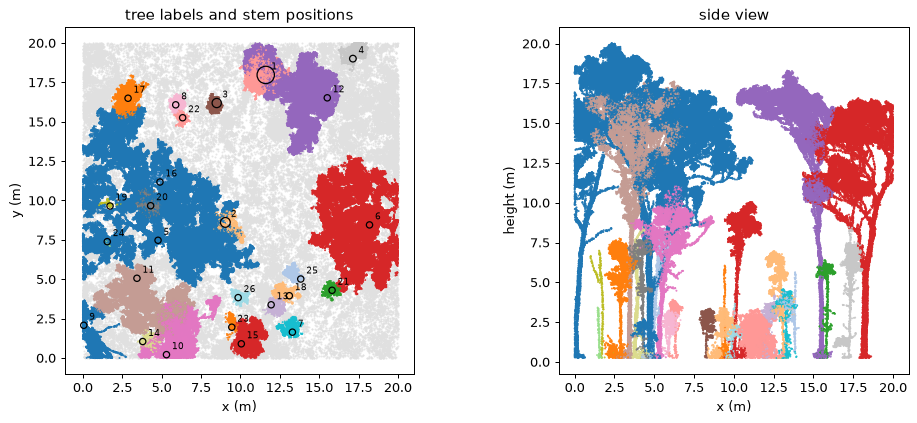

In [4]:
m = labels > 0
shuffle = np.random.default_rng(3).permutation(labels.max() + 2)   # neighbouring trees get unlike colours
colour = shuffle[labels] % 20
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(cloud.x[~m][::10], cloud.y[~m][::10], s=0.2, c="0.88")
ax[0].scatter(cloud.x[m][::4], cloud.y[m][::4], c=colour[m][::4], s=0.3, cmap="tab20")
for t in stems:
    ax[0].add_patch(plt.Circle((t.x, t.y), max(t.dbh / 2, 0.2), fill=False, color="k", lw=1.0))
    ax[0].annotate(str(t.tree_id), (t.x + 0.35, t.y + 0.35), fontsize=7)
ax[0].set(title="tree labels and stem positions", xlabel="x (m)", ylabel="y (m)", aspect="equal")
ax[1].scatter(cloud.x[m][::4], cloud.attrs["height"][m][::4], c=colour[m][::4], s=0.3, cmap="tab20")
ax[1].set(title="side view", xlabel="x (m)", ylabel="height (m)", aspect="equal");

There is no field inventory for this tile, so treat the table as a
demonstration: detection and segmentation are scored against manually
segmented plots (including Litchfield) in
[Benchmarks](../benchmarks/trees.md). Where labels have to be right, correct
them by hand in [Segfix](https://github.com/tim-devereux/segfix), which reads
and writes the `tree_id` column:

In [5]:
ids = np.where(labels > 0, labels, 0).astype("int32")      # Segfix: 0 = unassigned
sylva.write(cloud.with_attrs(tree_id=ids), "tile_trees.laz")

## The tree table

`Tree.as_dict` and the crown metrics make one row per tree.

In [6]:
import pandas as pd

table = pd.DataFrame([{**t.as_dict(), **crowns.get(t.tree_id, {})} for t in stems])
table.to_csv("trees.csv", index=False)
table[["tree_id", "x", "y", "dbh", "height", "crown_area", "crown_depth", "quality"]].head(8).round(2)

,tree_id,x,y,dbh,height,crown_area,crown_depth,quality
0,1,11.61,17.97,1.10,3.09,7.30,2.89,0.16
1,2,9.05,8.61,0.62,3.31,2.71,2.92,0.11
2,3,8.50,16.19,0.59,3.27,1.02,1.87,0.08
3,4,17.14,19.01,0.42,7.90,1.72,4.47,0.11
4,5,4.77,7.47,0.32,19.40,94.92,10.04,0.49
5,6,18.20,8.45,0.30,16.23,40.85,6.07,0.48
6,7,13.30,1.64,0.28,4.46,1.56,2.08,0.09
7,8,5.89,16.07,0.28,3.15,1.26,1.77,0.07


The candidates with a large DBH but a height of about 3 m are shrub
and grass clumps that the slice fits read as wide stems. Their `quality` is
mostly around 0.1, against 0.5 for the real trees, but not always: one here
scores 0.16, so `prune_trees(..., min_quality_short=0.15)` misses it. A
`max_dbh`, or dropping wide stems that are short, removes them all. Measure
the taper on a tree that detection is confident about instead.

## Basal area

`basal_area` sums the stems' cross-sections at breast height, in m²/ha of the
area given; the tile is 20 × 20 m, and `min_dbh` sets an inventory threshold.
The shrub clumps dominate it, since basal area grows with DBH squared, so drop
the wide, short candidates first.

In [7]:
area = 20.0 * 20.0
real = [t for t in stems if not (t.dbh > 0.4 and t.height < 8)]
print(f"every candidate:         {trees.basal_area(stems, area):5.1f} m2/ha")
print(f"without wide and short:  {trees.basal_area(real, area):5.1f} m2/ha ({len(real)} stems)")
print(f"  and DBH >= 10 cm:      {trees.basal_area(real, area, min_dbh=0.1):5.1f} m2/ha")

every candidate:          54.3 m2/ha
without wide and short:   12.6 m2/ha (22 stems)
  and DBH >= 10 cm:       11.7 m2/ha


## Taper and crown shape

tree 5: DBH 0.316 m, height 19.4 m, crown volume 396 m3, asymmetry 0.36


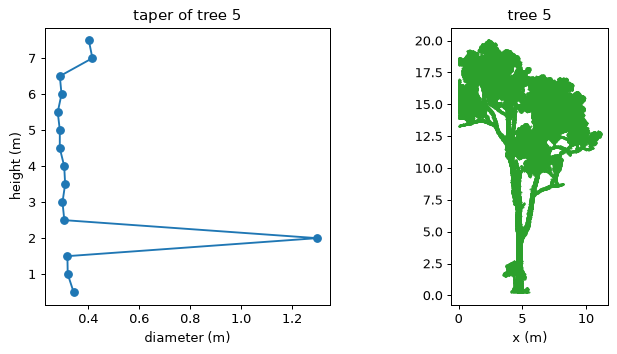

In [8]:
big = max(stems, key=lambda t: t.height)
diam = trees.dbh_profile(cloud, (big.x, big.y), heights=np.arange(0.5, 8.0, 0.5))
shape = trees.crown_shape(cloud[labels == big.tree_id], base_xy=(big.x, big.y))
print(f"tree {big.tree_id}: DBH {big.dbh:.3f} m, height {big.height:.1f} m, "
      f"crown volume {shape['volume']:.0f} m3, asymmetry {shape['asymmetry']:.2f}")
fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].plot(diam[:, 1], diam[:, 0], "o-")
ax[0].set(xlabel="diameter (m)", ylabel="height (m)", title=f"taper of tree {big.tree_id}")
sel = labels == big.tree_id
ax[1].scatter(cloud.x[sel], cloud.attrs["height"][sel], s=0.3, c="C2")
ax[1].set(xlabel="x (m)", title=f"tree {big.tree_id}", aspect="equal");